# Exercise 03: Bar charts

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

## Loading data

In [2]:
df = pd.read_sql("""
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%'
""", conn, parse_dates=['timestamp'])

## Extracting features 

In [3]:
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5
df['date'] = df['timestamp'].dt.date

## Counting commits per day+hour

In [4]:
counts = df.groupby(['date', 'hour', 'is_weekend']).size().reset_index(name='commits')

## Average commits per hour

In [5]:
avg = counts.groupby(['hour', 'is_weekend'])['commits'].mean().unstack()
avg.columns = ['working_day', 'weekend'] 
avg = avg[['weekend', 'working_day']]

In [6]:
df['date'] = df['timestamp'].dt.date
counts = df.groupby(['date', 'hour', 'is_weekend']).size().reset_index(name='commits')

## Plotting bar charts 

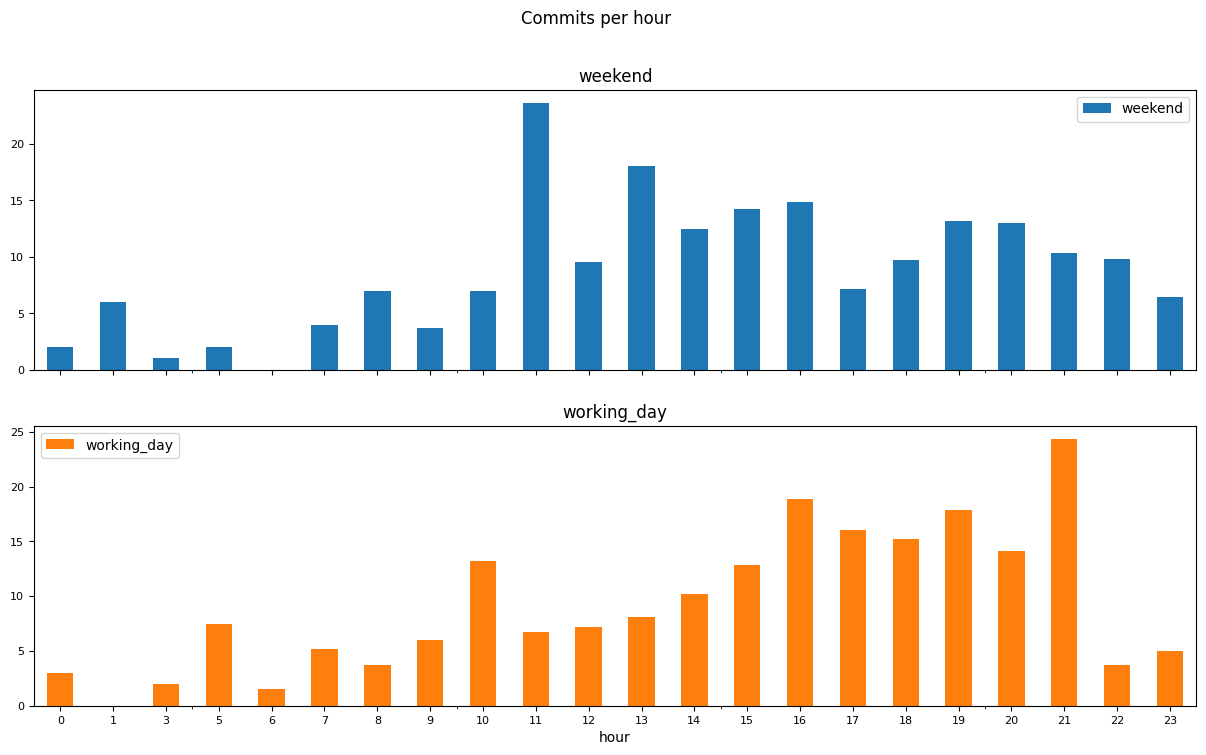

In [7]:
ax = avg.plot(
    kind='bar',
    subplots=True,   
    figsize=(15,8),
    fontsize=8,
    sharex=True,
    rot=0,
    title = 'Commits per hour'
)

for a in ax:
    a.set_xlabel('hour')

##### Is the dynamic different on working days and weekends?

Yes.
The highest number of commits on working days is at hour 21.
The highest number of commits on weekends is at hour 11.

## Closing connection

In [8]:
conn.close()